<a href="https://colab.research.google.com/github/Shiyasalloor/Image_and_Video_processing_lab/blob/main/Set_3_Question_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [2]:
img = cv2.imread('blobs.png', cv2.IMREAD_COLOR)
if img is None:
    # Generate a synthetic example if no image found
    img = np.zeros((200, 300), dtype=np.uint8)
    cv2.circle(img, (50, 100), 20, 255, -1)
    cv2.circle(img, (150, 50), 15, 255, -1)
    cv2.circle(img, (250, 130), 25, 255, -1)
    img = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

_, binary = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)

num_labels, labels_im = cv2.connectedComponents(binary)


In [3]:
label_hue = np.uint8(179 * labels_im / np.max(labels_im))
blank_ch = 255 * np.ones_like(label_hue)
segmented_img = cv2.merge([label_hue, blank_ch, blank_ch])
segmented_img = cv2.cvtColor(segmented_img, cv2.COLOR_HSV2BGR)
segmented_img[label_hue == 0] = 0

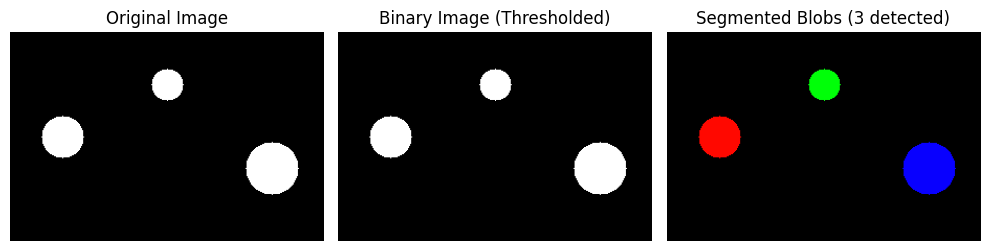

In [5]:
plt.figure(figsize=(10,4))
plt.subplot(1,3,1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(binary, cmap='gray')
plt.title("Binary Image (Thresholded)")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(segmented_img)
plt.title(f"Segmented Blobs ({num_labels-1} detected)")
plt.axis("off")

plt.tight_layout()
plt.show()
